In [46]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [47]:
def driven_energies_approx_pm(Delta_OmegaDrive_ratio):
    # compute the approximate energies of the driven qubit. The outputed energy are ratio of E to omega_drive (hbar = 1)
    E_plus = (1/4) * np.abs(1/Delta_OmegaDrive_ratio) * (1 + 2*Delta_OmegaDrive_ratio**2)
    return E_plus, -E_plus # first is E_plus, second is E_minus
def driven_energies_exact_pm(Delta_OmegaDrive_ratio):
    # compute the exact energies of the driven qubit. The outputed energy are ratio of E to omega_drive (hbar = 1)
    E_plus = (1/2)*np.sqrt(1 + Delta_OmegaDrive_ratio**2)
    return E_plus, -E_plus # first is E_plus, second is E_minus
def P_01(tau, Delta_OmegaDrive_ratio):
    # compute the probability of being in the excited state after time tau, given detuning to drive ratio Delta_OmegaDrive_ratio. We started in the ground state at t=0. tau = t * omega_drive
    Omega_R = np.sqrt(1 + Delta_OmegaDrive_ratio**2) # Rabi frequency normalized to omega_drive
    P_01 = (1/(1 + Delta_OmegaDrive_ratio**2)) * (np.sin(Omega_R * tau / 2))**2
    return P_01
def P_00(tau, Delta_OmegaDrive_ratio):
    # compute the probability of being in the ground state after time tau, given detuning to drive ratio Delta_OmegaDrive_ratio. We started in the ground state at t=0. tau = t * omega_drive
    return 1 - P_01(tau, Delta_OmegaDrive_ratio)
def P_00_time_avg(Delta_OmegaDrive_ratio):
    # compute the time-averaged probability of being in the ground state, given detuning to drive ratio Delta_OmegaDrive_ratio. We started in the ground state at t=0.
    return 1-(1/(2*(1 + Delta_OmegaDrive_ratio**2)))

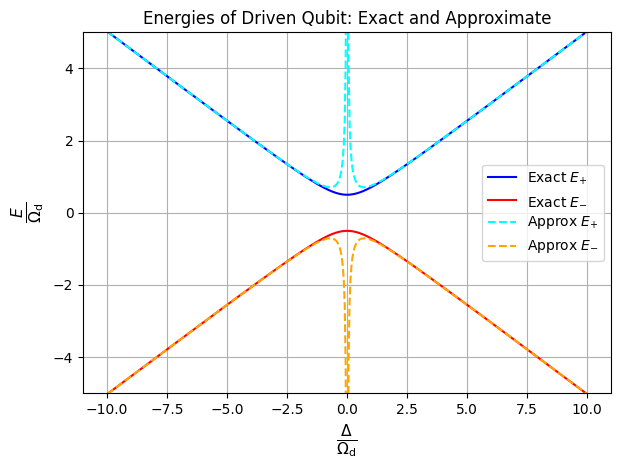

In [48]:
Delta_OmegaDrive_max = 10
num_points = 500

Delta_OmegaDrive_ratio_array = np.linspace(-Delta_OmegaDrive_max, Delta_OmegaDrive_max, num_points)

plt.figure()
plt.plot(Delta_OmegaDrive_ratio_array, driven_energies_exact_pm(Delta_OmegaDrive_ratio_array)[0], label=r'Exact $E_{+}$', color='blue')
plt.plot(Delta_OmegaDrive_ratio_array, driven_energies_exact_pm(Delta_OmegaDrive_ratio_array)[1], label=r'Exact $E_{-}$', color='red')
plt.plot(Delta_OmegaDrive_ratio_array, driven_energies_approx_pm(Delta_OmegaDrive_ratio_array)[0], '--', label=r'Approx $E_{+}$', color='cyan')
plt.plot(Delta_OmegaDrive_ratio_array, driven_energies_approx_pm(Delta_OmegaDrive_ratio_array)[1], '--', label=r'Approx $E_{-}$', color='orange')
plt.xlabel(r'$\frac{\Delta}{\Omega_{\mathrm{d}}}$', fontsize=16)
plt.ylabel(r'$\frac{E}{\Omega_{\mathrm{d}}}$', fontsize=16)
plt.title('Energies of Driven Qubit: Exact and Approximate')
plt.legend()
plt.grid()
plt.tight_layout()
plt.ylim(-5,5)
plt.show()

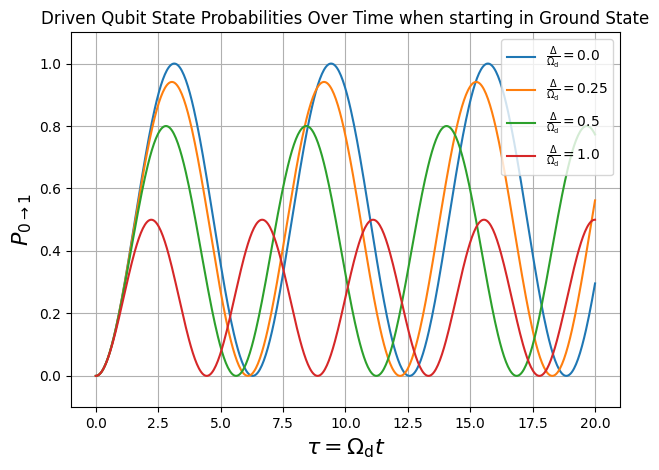

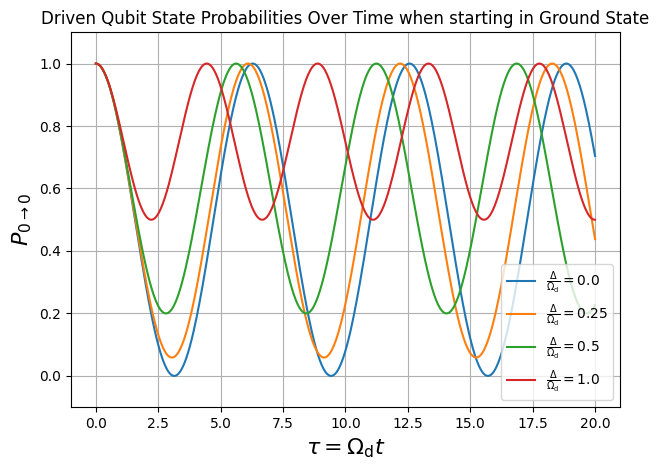

In [49]:
Delta_OmegaDrive_ratio_array = np.array([0,0.25,0.5,1])
tau_array = np.linspace(0, 20, 500)

plt.figure()
for Delta_OmegaDrive_ratio in Delta_OmegaDrive_ratio_array:
    plt.plot(tau_array, P_01(tau_array, Delta_OmegaDrive_ratio), label=r'$\frac{\Delta}{\Omega_{\mathrm{d}}}=$' + f'{Delta_OmegaDrive_ratio}')
plt.xlabel(r'$\tau = \Omega_{\mathrm{d}} t$', fontsize=16)
plt.ylabel(r'$P_{0 \to 1}$', fontsize=16)
plt.title('Driven Qubit State Probabilities Over Time when starting in Ground State')
plt.legend()
plt.grid()
plt.tight_layout()
plt.ylim(-0.1,1.1)
plt.show()

plt.figure()
for Delta_OmegaDrive_ratio in Delta_OmegaDrive_ratio_array:
    plt.plot(tau_array, P_00(tau_array, Delta_OmegaDrive_ratio), '-', label=r'$\frac{\Delta}{\Omega_{\mathrm{d}}}=$' + f'{Delta_OmegaDrive_ratio}')
plt.xlabel(r'$\tau = \Omega_{\mathrm{d}} t$', fontsize=16)
plt.ylabel(r'$P_{0 \to 0}$', fontsize=16)
plt.title('Driven Qubit State Probabilities Over Time when starting in Ground State')
plt.legend()
plt.grid()
plt.tight_layout()
plt.ylim(-0.1,1.1)
plt.show()

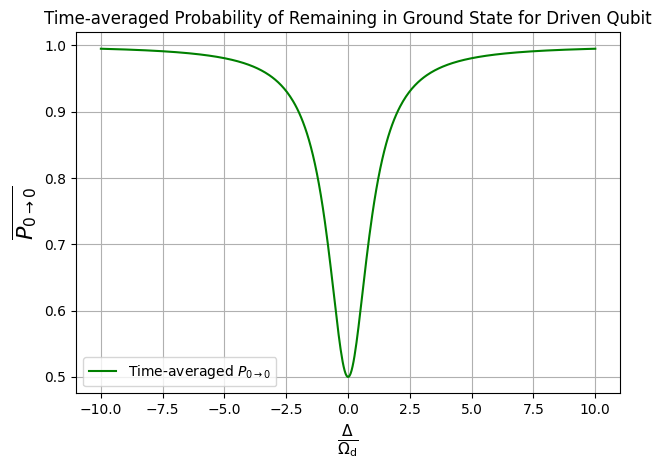

In [50]:
Delta_OmegaDrive_max = 10
num_points = 500

Delta_OmegaDrive_ratio_array = np.linspace(-Delta_OmegaDrive_max, Delta_OmegaDrive_max, num_points)

plt.figure()
plt.plot(Delta_OmegaDrive_ratio_array, P_00_time_avg(Delta_OmegaDrive_ratio_array), label=r'Time-averaged $P_{0 \to 0}$', color='green')
plt.xlabel(r'$\frac{\Delta}{\Omega_{\mathrm{d}}}$', fontsize=16)
plt.ylabel(r'$\overline{P_{0 \to 0}}$', fontsize=16)
plt.title('Time-averaged Probability of Remaining in Ground State for Driven Qubit')
plt.legend()
plt.grid()
plt.tight_layout()
# plt.ylim(-0.1,0.6)
plt.show()

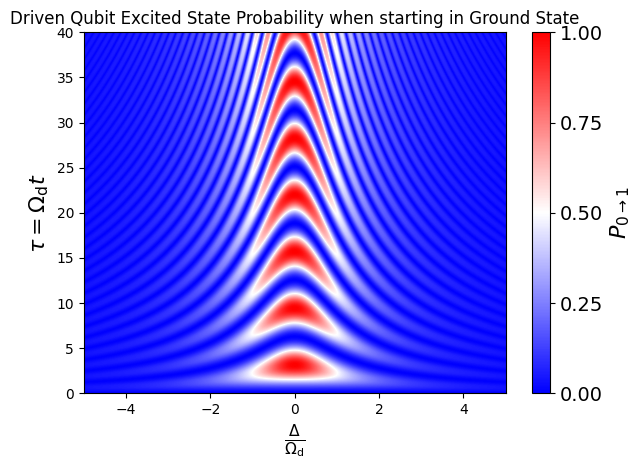

In [82]:
num_points = 1000
tau_array = np.linspace(0, 40, num_points)
Delta_OmegaDrive_max = 5
Delta_OmegaDrive_ratio_array = np.linspace(-Delta_OmegaDrive_max, Delta_OmegaDrive_max, num_points)

Delta_OmegaDrive_ratio_meshgrid, tau_meshgrid = np.meshgrid(Delta_OmegaDrive_ratio_array, tau_array)
P_01_meshgrid = P_01(tau_meshgrid, Delta_OmegaDrive_ratio_meshgrid)
plt.figure()
plt.contourf(Delta_OmegaDrive_ratio_array, tau_array, P_01_meshgrid, levels=500, cmap='bwr')

cbar = plt.colorbar()
cbar.set_label(r'$P_{0 \to 1}$', fontsize=16)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.tick_params(labelsize=14) 

plt.xlabel(r'$\frac{\Delta}{\Omega_{\mathrm{d}}}$', fontsize=16)
plt.ylabel(r'$\tau = \Omega_{\mathrm{d}} t$', fontsize=16)
plt.title('Driven Qubit Excited State Probability when starting in Ground State')
plt.tight_layout()
plt.show()
